In [69]:
from sedona.spark import SedonaContext
import os
import geopandas as gpd
from IPython.display import HTML
from shapely.wkt import loads

In [70]:
def show_map(m):
    return HTML(f"<div style='width:800px; height:500px'>{m._repr_html_()}</div>")

In [3]:
!pip install mapclassify folium


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [35]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext

# Geometry constructors

In [36]:
sedona.sql(
    """
    SELECT ST_GeomFromText('POINT (151.241012 -33.843705)') AS geom
    """
).show()

+--------------------+
|                geom|
+--------------------+
|POINT (151.241012...|
+--------------------+



In [37]:
sedona.sql(
    """
    SELECT ST_GeomFromText('POINT (151.241012 -33.843705)') AS geom
        
    """
).createOrReplaceTempView("points")

# Geometry functions

In [38]:
sedona.sql(
    """
    SELECT 
        ST_GeometryType(geom) AS geom_type
    FROM points
        
    """
).show()

+---------+
|geom_type|
+---------+
| ST_Point|
+---------+



In [39]:
sedona.sql(
    """
    SELECT 
        ST_SRID(geom) AS srid
    FROM points
    """
).show()

+----+
|srid|
+----+
|   0|
+----+



In [40]:
sedona.sql(
    """
    SELECT 
        ST_Transform(ST_SetSRID(geom, 4326), 'EPSG:3857') AS geom
    FROM points
    """
).show(1, False)

+---------------------------------------------+
|geom                                         |
+---------------------------------------------+
|POINT (16836072.44289938 -4007834.6839636774)|
+---------------------------------------------+



In [41]:
sedona.sql(
    """
    SELECT 
        ST_SRID(ST_Transform(ST_SetSRID(geom, 4326), 'EPSG:3857')) AS geom
    FROM points
    """
).show(1, False)

+----+
|geom|
+----+
|3857|
+----+



# Distance functions

In [42]:
# point inside polygon, distance 0

In [43]:
sedona.sql(
    """
    SELECT ST_Distance(
        ST_GeomFromText('Point(0 0)'),
        ST_GeomFromText('Polygon((-1 -1, -1 2, 2 2, 2 -1, -1 -1))')
    ) AS dist
    """
).show()

+----+
|dist|
+----+
| 0.0|
+----+



In [44]:
# normal distance

In [45]:
sedona.sql(
    """
    SELECT ST_Distance(
        ST_GeomFromText('Point(-2 -2)'),
        ST_GeomFromText('Polygon((-1 -1, -1 2, 2 2, 2 -1, -1 -1))')
    ) AS dist
    """
).show()

+------------------+
|              dist|
+------------------+
|1.4142135623730951|
+------------------+



In [46]:
sedona.sql(
    """
    SELECT ST_Distance(
        ST_GeomFromText('Point(-2 -2)'),
        ST_GeomFromText('Polygon((2 2, 2 -1, -1 -1, -1 2, 2 2))')
    ) AS dist
    """
).show()

+------------------+
|              dist|
+------------------+
|1.4142135623730951|
+------------------+



In [47]:
# distance between closest points

In [48]:
sedona.sql(
    """
    SELECT ST_Distance(
        ST_GeomFromText('Point(-2 -2)'),
        ST_GeomFromText('Point(-1 -1)')
    ) AS dist
    """
).show()

+------------------+
|              dist|
+------------------+
|1.4142135623730951|
+------------------+



In [49]:
sedona.sql(
    """
    SELECT ST_Distance(
        ST_GeomFromText('Point(-2 -2)'),
        ST_GeomFromText('Point(2 2)')
    ) AS dist
    """
).show()

+-----------------+
|             dist|
+-----------------+
|5.656854249492381|
+-----------------+



In [50]:
## distance to centroid

In [51]:
sedona.sql(
    """
    SELECT ST_Distance(
        ST_GeomFromText('Point(-2 -2)'),
        ST_Centroid(ST_GeomFromText('Polygon((-1 -1, -1 2, 2 2, 2 -1, -1 -1))'))
    ) AS dist
    """
).show()

+------------------+
|              dist|
+------------------+
|3.5355339059327378|
+------------------+



In [52]:
# share common points geometries

In [53]:
geom_left = "Polygon((-1 -1, 2 3, 2 2, 2 -1, -1 -1))"
geom_right = "Polygon((-1 -1, -1 2, 2 2, 2 -1, -1 -1))"

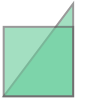

In [54]:
loads(f'GEOMETRYCOLLECTION({geom_left}, {geom_right})')

In [55]:
sedona.sql(
    f"""
    SELECT ST_Distance(
        ST_GeomFromText('{geom_left}'),
        ST_GeomFromText('{geom_right}')
    ) AS dist
    """
).show()

+----+
|dist|
+----+
| 0.0|
+----+



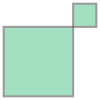

In [56]:
geom_left = "Polygon((2 2, 2 3, 3 3, 3 2, 2 2))"
geom_right = "Polygon((-1 -1, -1 2, 2 2, 2 -1, -1 -1))"
loads(f'GEOMETRYCOLLECTION({geom_left}, {geom_right})')

In [57]:
sedona.sql(
    f"""
    SELECT ST_Distance(
        ST_GeomFromText('{geom_left}'),
        ST_GeomFromText('{geom_right}')
    ) AS dist
    """
).show()

+----+
|dist|
+----+
| 0.0|
+----+



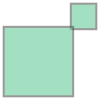

In [58]:
geom_left = "Polygon((1.9 1.9, 1.9 3, 3 3, 3 1.9, 1.9 1.9))"
geom_right = "Polygon((-1 -1, -1 2, 2 2, 2 -1, -1 -1))"
loads(f'GEOMETRYCOLLECTION({geom_left}, {geom_right})')

In [59]:
sedona.sql(
    f"""
    SELECT ST_Distance(
        ST_GeomFromText('{geom_left}'),
        ST_GeomFromText('{geom_right}')
    ) AS dist
    """
).show()

+----+
|dist|
+----+
| 0.0|
+----+



# Transforming Vietnam road Data

In [60]:
roads = sedona.\
    read.\
    format("shapefile").\
    load(f"s3a://{bucket_name}/source_data/vietnam_roads/gis_osm_roads_free_1.shp")

roads.createOrReplaceTempView("roads")
roads.cache().count()

3022375

# ST_Simplify function

In [61]:
show_map(gpd.GeoDataFrame(roads.where("osm_id=211733913").selectExpr("ST_Simplify(geometry, 0.01) AS geometry").toPandas(), geometry="geometry").explore(   zoom_start=11,))

In [62]:
show_map(gpd.GeoDataFrame(roads.where("osm_id=211733913").selectExpr("geometry").toPandas(), geometry="geometry").explore(   zoom_start=11,))

In [63]:
roads.select("osm_id", "name", "fclass", "geometry").show(5)

+-------+----------------+-----------+--------------------+
| osm_id|            name|     fclass|            geometry|
+-------+----------------+-----------+--------------------+
|9566542|     Cầu Thê Húc|    footway|LINESTRING (105.8...|
|9656653|      Phố Mã Mây|residential|LINESTRING (105.8...|
|9656730|Cầu Chương Dương|    primary|LINESTRING (105.8...|
|9963509|    Phố Hàng Cót|   tertiary|LINESTRING (105.8...|
|9964440|Phố Quốc Tử Giám|residential|LINESTRING (105.8...|
+-------+----------------+-----------+--------------------+
only showing top 5 rows



# Preparing data for routing dataset, using the ST_StartPoint and ST_EndPoint function

In [64]:
sedona.sql(
"""
    SELECT 
        osm_id as id,
        ST_StartPoint(geometry) AS geom
    FROM roads
    UNION ALL
    SELECT 
        osm_id as id,
        ST_EndPoint(geometry) AS geom
    FROM roads
"""    
).show()

+--------+--------------------+
|      id|                geom|
+--------+--------------------+
| 9566542|POINT (105.852999...|
| 9656653|POINT (105.853446...|
| 9656730|POINT (105.865640...|
| 9963509|POINT (105.847163...|
| 9964440|POINT (105.838099...|
| 9964551|POINT (105.82426 ...|
| 9964663|POINT (105.842177...|
| 9965723|POINT (105.853230...|
| 9975059|POINT (105.888769...|
| 9978719|POINT (105.893973...|
|10045075|POINT (105.801391...|
|10046571|POINT (105.798351...|
|10047796|POINT (105.778322...|
|10047852|POINT (105.841426...|
|10047949|POINT (105.845505...|
|10048048|POINT (105.843671...|
|10048345|POINT (105.778322...|
|10049443|POINT (105.810260...|
|10049446|POINT (105.818639...|
|10230410|POINT (105.855307...|
+--------+--------------------+
only showing top 20 rows



# Finding roads to block before marathon using the ST_ConvexHull function

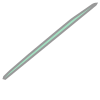

In [65]:
sedona.sql(
    """
    SELECT 
        ST_ConvexHull(ST_Union_Aggr(geometry))
    FROM roads 
    WHERE (name = 'Phố Giảng Võ' or name = 'Phố Kim Mã') and fclass = 'primary'
    """
    
).collect()[0][0]

In [66]:
sedona.sql(
    """
    SELECT ST_ConvexHull(ST_Union_Aggr(geometry)) AS geom
    FROM roads 
    where (name = 'Phố Giảng Võ' or name = 'Phố Kim Mã') and fclass = 'primary'
    """
    
).createOrReplaceTempView("convex_hull")

In [67]:
sedona.sql(
    """
    SELECT DISTINCT name
    FROM roads
    WHERE ST_Intersects(geometry, (
        SELECT
            ST_Transform(
                ST_Buffer(
                    ST_Transform(geom, 'EPSG:3405'),
                    500
                ),
                'EPSG:4326'
            ) as geom
        FROM convex_hull
    ))
    """
).show(5)

[Stage 54:>                                                         (0 + 1) / 1]

+--------------------+
|                name|
+--------------------+
|     Ngõ 152 Hào Nam|
|      Ngõ Quan Thổ 1|
|   Ngõ 20 Thành Công|
| Ngõ 8B Phố Vũ Thạnh|
|Ngõ 156 Mai Anh Tuấn|
+--------------------+
only showing top 5 rows



In [68]:
sedona.sql(
    """
    SELECT DISTINCT name
    FROM roads
    WHERE ST_DWithin(geometry, (SELECT geom FROM convex_hull), 500, true)
    """
).show()

[Stage 60:>                                                         (0 + 1) / 1]

+--------------------+
|                name|
+--------------------+
| Ngõ 8B Phố Vũ Thạnh|
|Ngách 6 Ngõ 189 G...|
|    Ngõ 20A Núi Trúc|
|Ngách 1 Ngõ 2 Vũ ...|
|    Ngõ 149 Giảng Võ|
|     Ngõ 127 Hào Nam|
|     Ngõ 29 Vũ Thạnh|
|    Ngõ 187 Giảng Võ|
|      Ngõ 39 Hào Nam|
|Ngách 99 Ngõ 318 ...|
|Ngách 48 Ngõ 29 V...|
| Ngõ 466 Đê La Thành|
|         Phố Nam Cao|
|Ngõ 418 Đường La ...|
|     Ngõ 167 Hào Nam|
|     Ngõ 95 Giảng Võ|
|Ngách 360/4 La Thành|
|        Phố Vũ Thạnh|
|Ngách 23 Ngõ 127 ...|
|Hẻm 1 Ngách 1 Ngõ...|
+--------------------+
only showing top 20 rows

